Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below:

In [1]:
NAME = "Santi Toribio"
COLLABORATORS = "N/A"

---

# Final Project

This is where you will complete your final project for CS115 Fall 2025.

Be sure to carefully address ALL of the deliverables outlined in the proposal notebook.

# Examining Statistics of NBA Players' Rookie Years
## By: Santi Toribio
### Dependencies: 
Pandas, NumPy, MatPlotLib, Seaborn
### Description:
This project is all about analyzing the different statistics between NBA players' rookie years. An NBA player's "rookie year" is defined as their first year of playing. "Analyzing" the different statistics of each of the NBA players entails a variety of different ways of analysis--in this project, I mainly used histograms and scatter plots to not only display trends on what the averages/outliers of a specific statistic are, but also to draw correlations and other relationships between the different variables.
### Table of Contents
##### Part 1: Importation and the Dataframe
##### Part 2: Averages and Statistics
##### Part 3: Correlation and Analysis
##### Part 4: Who's the Best?
##### Part 5: Reflection

## Part 1: Importation and the Dataframe
First, we have to import all of the necessary libraries for the project, which as listed above, are NumPy (necessary for computation and arrays and an essential element of the other libraries), Pandas (creates dataframes), MatPlotLib (graphing and is the base for Seaborn), and Seaborn (an extension of MatPlotLib). Additionally, we have to create the actual dataframe for the data, so we do so by using the "read_csv" function for pandas in order to read "nba_data.csv," and we assign this data to the variable "df_nba," which we will be using for the rest of the project.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_nba = pd.read_csv('nba_data.csv')
df_nba

,Name,GP,MIN,PTS,FGS,FGA,3PM,3PA,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,0.5,2.1,1.6,2.3,0.7,3.4,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,0.7,2.8,2.6,3.4,0.5,2.0,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,0.4,1.7,0.9,1.3,0.5,1.7,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,0.1,0.5,0.9,1.3,1.0,0.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,0.0,0.1,1.3,1.9,1.0,1.5,0.3,0.3,0.4,0.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303,Chris Smith,80,15.8,4.3,1.6,3.6,0.0,0.2,1.2,1.5,0.4,0.8,2.5,0.6,0.2,0.8,0
1304,Brent Price,68,12.6,3.9,1.5,4.1,0.1,0.7,0.8,1.0,0.4,1.1,2.3,0.8,0.0,1.3,1
1305,Marlon Maxey,43,12.1,5.4,2.2,3.9,0.0,0.0,1.0,1.6,1.5,2.3,0.3,0.3,0.4,0.9,0
1306,Litterial Green,52,12.0,4.5,1.7,3.8,0.0,0.2,1.2,1.8,0.2,0.4,2.2,0.4,0.1,0.8,1


What is printed/displayed is the dataframe that consists of the data from the rookie year of every NBA player who started playing between 1990 and 2016 (newer players have lower index numbers). However, there is a lot of terminology that may be unclear to those who are unfamiliar with basketball and/or basketball statistics. Here is a list of definitions:\
\
*Note that all values, with the exception of "GP" and "5Yrs" are averages PER GAME\
**GP** = Games Played\
**MIN** = Minutes Played per Game\
**PTS** = Points\
**FGS/A** = Field Goals (regular game shots) Made/Attempted\
**3PM/A** = Three-Pointers Made/Attempted\
**FTM/A** = Free Throws Made/Attempted\
**OREB** = Offensive Rebounds\
**DREB** = Defensive Rebounds\
**AST** = Assists\
**STL** = Steals\
**BLK** = Blocks\
**TOV** = Turnovers\
\
However, there are some tweaks to this dataframe that I would like to make. First, the "5Yrs" column doesn't apply to the project, so we can drop it. Additionally, I would like to add two columns, Offensive and Defensive Ratings (ORTG and DRTG respectively).\
*Note that the equations aren't entirely accurate to the actual, real statistic that's officially calculated (especially for ORTG, not only because the official equation includes numbers that are not present in the statistics, but also because the equation would also include dividing by 0 for some players), but for the purposes of the project, as well as the limitations of the data itself, the equation is enough. Also, I'll be changing the "3PM" and "3PA" columns to "TPM" and "TPA" to make it easier to call later in the project.

In [3]:
df_nba = pd.read_csv('nba_data.csv')
df_nba = df_nba.rename(columns={'3PM': 'TPM', '3PA': 'TPA'}) # Changes the first character to a letter instead of an int, to help call later.
df_nba = df_nba.drop('5Yrs', axis = 1)

ortg = round((((df_nba.PTS / 2) * (df_nba.AST / 4) + df_nba.OREB) + (df_nba.FTM * df_nba.TPM) + (df_nba.FGS)), 2)
drtg = df_nba.DREB + (df_nba.BLK * df_nba.STL)

df_nba['ORTG'] = pd.Series(ortg)
df_nba['DRTG'] = pd.Series(drtg)

df_nba

,Name,GP,MIN,PTS,FGS,FGA,TPM,TPA,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,ORTG,DRTG
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,0.5,2.1,1.6,2.3,0.7,3.4,1.9,0.4,0.4,1.3,5.86,3.56
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,0.7,2.8,2.6,3.4,0.5,2.0,3.7,1.1,0.5,1.6,7.65,2.55
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,0.4,1.7,0.9,1.3,0.5,1.7,1.0,0.5,0.3,1.0,3.51,1.85
3,Malik Sealy,58,11.6,5.7,2.3,5.5,0.1,0.5,0.9,1.3,1.0,0.9,0.8,0.6,0.1,1.0,3.96,0.96
4,Matt Geiger,48,11.5,4.5,1.6,3.0,0.0,0.1,1.3,1.9,1.0,1.5,0.3,0.3,0.4,0.8,2.77,1.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303,Chris Smith,80,15.8,4.3,1.6,3.6,0.0,0.2,1.2,1.5,0.4,0.8,2.5,0.6,0.2,0.8,3.34,0.92
1304,Brent Price,68,12.6,3.9,1.5,4.1,0.1,0.7,0.8,1.0,0.4,1.1,2.3,0.8,0.0,1.3,3.10,1.10
1305,Marlon Maxey,43,12.1,5.4,2.2,3.9,0.0,0.0,1.0,1.6,1.5,2.3,0.3,0.3,0.4,0.9,3.90,2.42
1306,Litterial Green,52,12.0,4.5,1.7,3.8,0.0,0.2,1.2,1.8,0.2,0.4,2.2,0.4,0.1,0.8,3.14,0.44


## Part 2: Averages and Statistics
This second part of the project is observing the individual graphs of the statistics. This is mainly done through the use of histograms, used to display the spread of each statistic. First, let's look at one of the most basic statistics--points per game.

Text(0.5, 1.0, "Histogram of Rookie NBA Players' PPG")

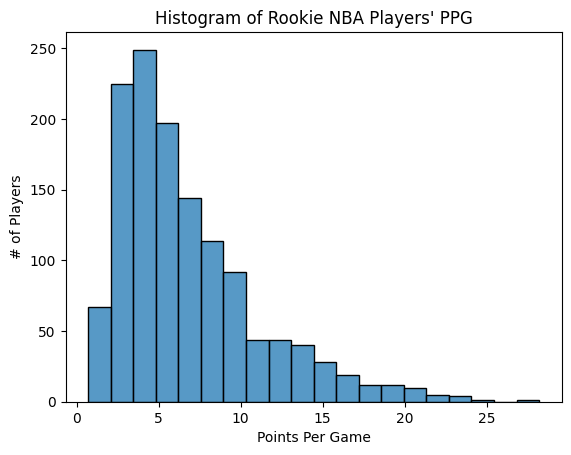

In [4]:
sns.histplot(df_nba.PTS, bins = 20)
plt.xlabel('Points Per Game')
plt.ylabel('# of Players')
plt.title("Histogram of Rookie NBA Players' PPG")

Text(0.5, 1.0, "Boxplot of Rookie NBA Players' PPG")

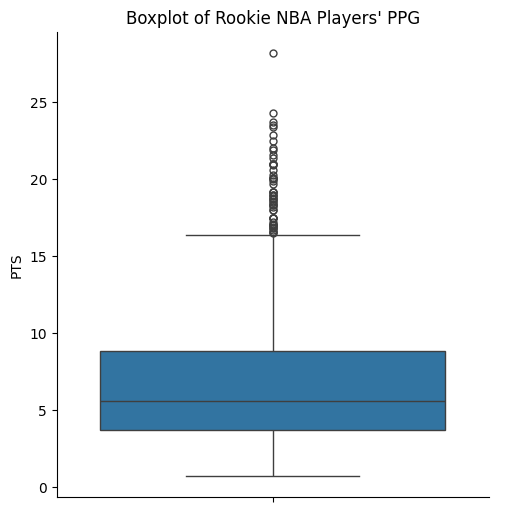

In [5]:
sns.catplot(kind = 'box', data = df_nba, y = df_nba.PTS)
plt.title("Boxplot of Rookie NBA Players' PPG")

As we see, the histogram of the distribution is very skewed right. A large majority of NBA players in their rookie year averaged between 0 and 10 points per game, with some outliers to the right of the mean who hover from anywhere between 15 and 27-28 points. The fact that these higher statistics are outliers are backed up by the boxplot--all of those dots are outliers, showing that a large majority of players don't achieve that level of greatness. Next, let's look at assists per game and see if the distribution is similar.

<Axes: title={'center': "Histogram of Rookie NBA Players' APG"}, xlabel='Assists Per Game', ylabel='# of Players'>

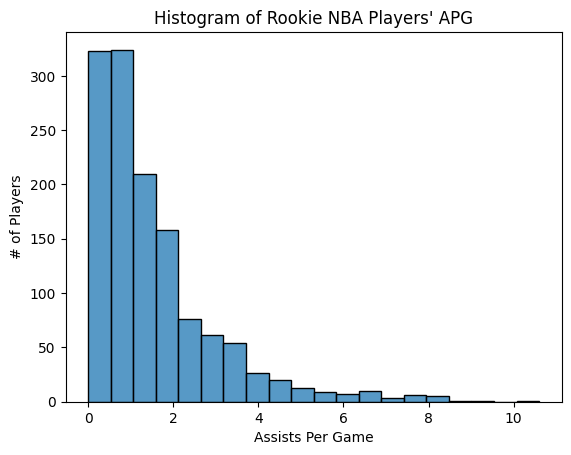

In [6]:
plt.xlabel('Assists Per Game')
plt.ylabel('# of Players')
plt.title("Histogram of Rookie NBA Players' APG")
sns.histplot(df_nba.AST, bins = 20)

Again, a very similar distribution--extremely skewed right where a majority of players have between 0-2 assists per game, with only a few stretching into 8-10 assists per game. Let's see if this trend continues for the other main tracked statistics.

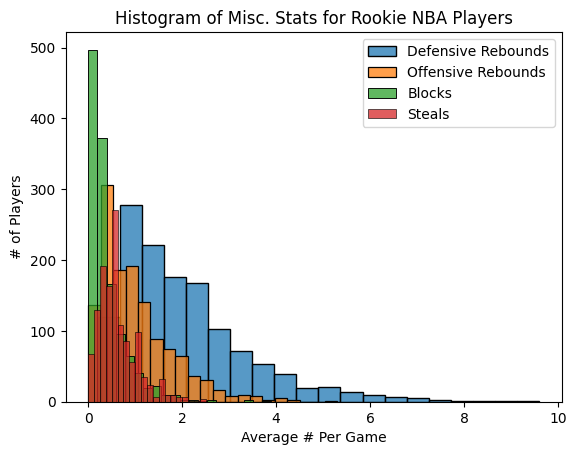

In [7]:
plt.xlabel('Average # Per Game')
plt.ylabel('# of Players')
sns.histplot(df_nba.DREB, bins = 20, label = 'Defensive Rebounds')
sns.histplot(df_nba.OREB, bins = 20, label = 'Offensive Rebounds')
sns.histplot(df_nba.BLK, bins = 20, label = 'Blocks')
sns.histplot(df_nba.STL, bins = 20, label = 'Steals')
plt.title("Histogram of Misc. Stats for Rookie NBA Players")
plt.legend()

Text(0.5, 1.0, 'Boxplot of Misc. Stats for Rookie NBA Players')

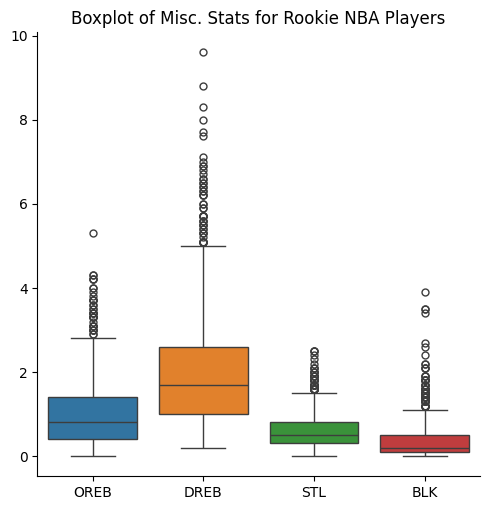

In [8]:
# Only want the four stats showed above
sns.catplot(kind = 'box', data = df_nba.drop(['GP','MIN','PTS','FGS','FGA','TPM','TPA','FTM','FTA','AST','TOV','ORTG','DRTG'], axis = 1))
plt.title('Boxplot of Misc. Stats for Rookie NBA Players')

As we see for both the histograms and boxplots, a majority of the players remain in the lower part of the distribution, while there are some outliers who go above and beyond. This phenomenon is primarily shown through defensive rebounds, which cover a very large range of statistics (~0-10), and blocks, where a large majority of players average ~0-0.5 blocks per game, but some get upwards of 4 block per game. The next graph compares offensive and defensive rating, and we see the same kind of distribution in those as well.

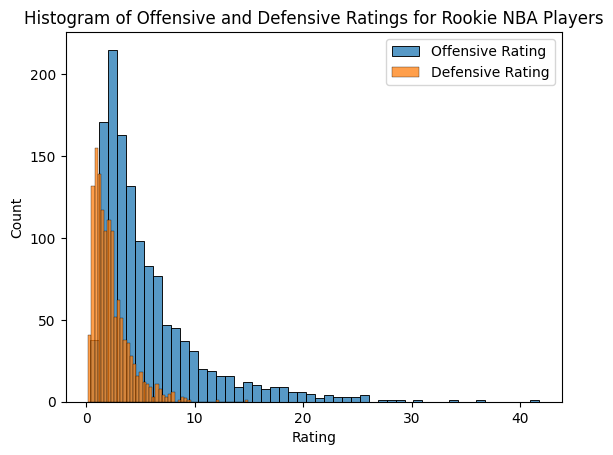

In [9]:
sns.histplot(x = df_nba.ORTG, bins = 50, label = 'Offensive Rating') # More bins than usual due to the variability for rating ranges
sns.histplot(x = df_nba.DRTG, bins = 50, label = 'Defensive Rating')
plt.xlabel('Rating')
plt.title('Histogram of Offensive and Defensive Ratings for Rookie NBA Players')
plt.legend()

Next, let's look at the kind of shots that players are making. Let's look at field goals, or regular shots made in a game, first.

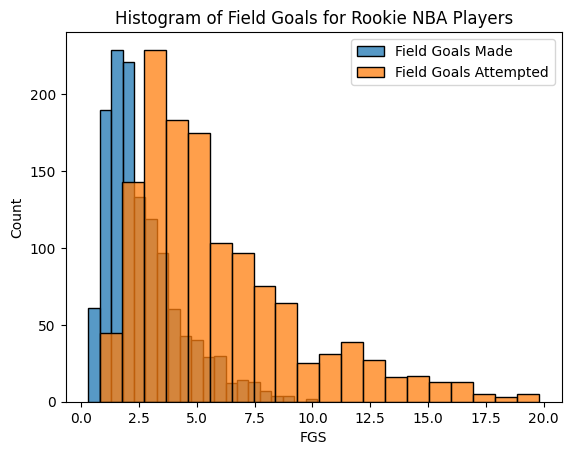

In [10]:
sns.histplot(df_nba.FGS, bins = 20, label = 'Field Goals Made')
sns.histplot(df_nba.FGA, bins = 20, label = 'Field Goals Attempted')
plt.title('Histogram of Field Goals for Rookie NBA Players')
plt.legend()

As shown in the graph above, we see the same kind of skewed-right distribution present in all of the other graphs. The histogram of field goals attempted is far greater than the histogram of field goals made, which makes sense as the number of field goals made is just a percent of the number of field goals attempted. It's also intersting that the histogram of field goals attempted is much more spread out than field goals made, or even more than all of the graphs so far. Next, let's look at the other metrics, free throws and three pointers.

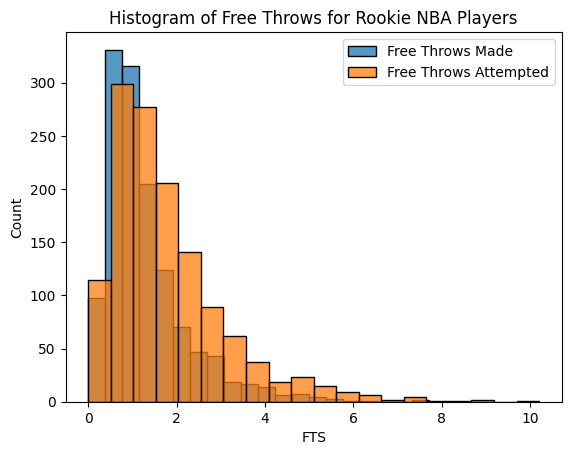

In [11]:
sns.histplot(df_nba.FTM, bins = 20, label = 'Free Throws Made')
sns.histplot(df_nba.FTA, bins = 20, label = 'Free Throws Attempted')
plt.xlabel('FTS')
plt.title('Histogram of Free Throws for Rookie NBA Players')
plt.legend()

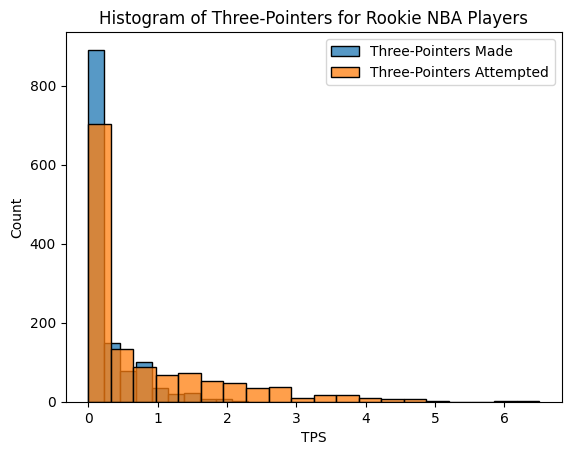

In [12]:
sns.histplot(df_nba.TPM, bins = 10, label = 'Three-Pointers Made')
sns.histplot(df_nba.TPA, bins = 20, label = 'Three-Pointers Attempted')
plt.xlabel('TPS')
plt.title('Histogram of Three-Pointers for Rookie NBA Players')
plt.legend()

We see the same kind of skewed-right distribution in both of these graphs. However, it's interesting that the histogram for three pointers is FAR MORE SKEWED than all of the statistics. In the boxplot below, we see that a LARGE MAJORITY of players have an average number of three pointers attempted per game of <1.0, while other players have one of >6.0.

Text(0.5, 1.0, 'Boxplot of Three-Pointers for Rookie NBA Players')

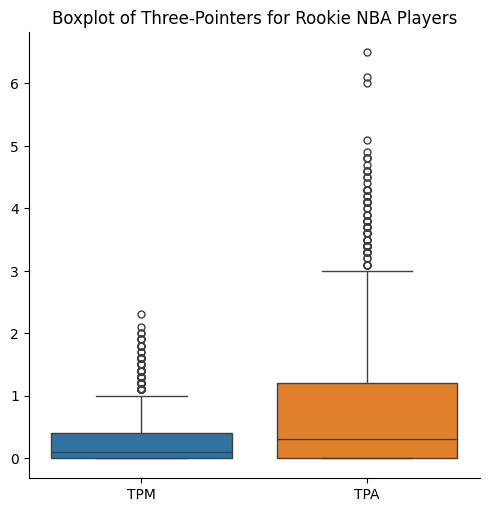

In [13]:
# We only want TPM and TPA
sns.catplot(kind = 'box', data = df_nba.drop(['GP','MIN','PTS','FGS','FGA','FTM','FTA','AST','BLK','STL','DREB','OREB','TOV','ORTG','DRTG'], axis = 1))
plt.title('Boxplot of Three-Pointers for Rookie NBA Players')

## Part 3: Correlation and Analysis
Let's move past histograms and boxplots and move onto something different--scatterplots and regression lines. The following graphs were all created with the following function, which plots a scatterplot of the data, creates a linear line that's of best fit, and automatically sets the limits so the graphs don't look too weird.\
\
Now, let's plot a graph relating games played and points per game just to see what a graph would look like.

Text(0.5, 1.0, 'Points on Games Played for Rookie NBA Players')

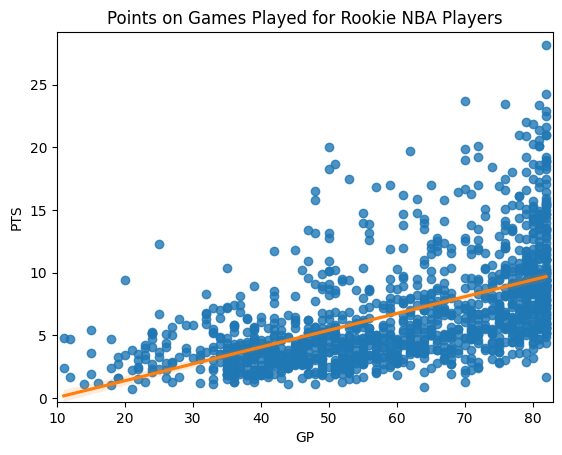

In [14]:
def scattreg(xval, yval):
    '''
    Creates a scatterplot and regression line based on the specified x and y values.
    The two arguments both have to be a series from the NBA Dataframe.
    Also automatically changes the limits of the plot in order to have a clearer plot with less empty space.
    '''
    if xval.max() > 10:
        plt.xlim(xval.min() - 1, xval.max() + 1)
    else:
        plt.xlim(xval.min() - 0.2, xval.max() + 0.2)

    if yval.max() > 10:
        plt.ylim(yval.min() - 1, yval.max() + 1)
    else:
        plt.ylim(yval.min() - 0.2, yval.max() + 0.2)
    sns.regplot(x = xval, y = yval,
                line_kws = {'color': 'C1'}) # Changes the color of the regression line to orange to make it pop out on the graph.

scattreg(df_nba.GP, df_nba.PTS)
plt.title('Points on Games Played for Rookie NBA Players')

Here, we see a slight upward trend for players regarding their games played in the season and average points per game, which makes sense as players who score more points tend to play in more games than those who don't. Let's now move onto another chart with two very related stats, defensive rebounds and blocks.

Text(0.5, 1.0, 'Blocks on Defensive Rebounds for Rookie NBA Players')

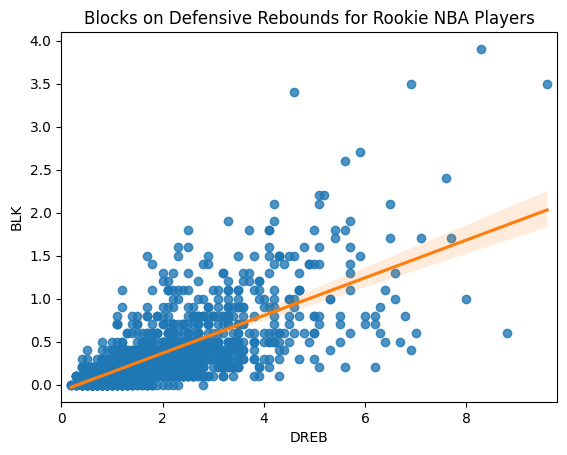

In [15]:
scattreg(df_nba.DREB, df_nba.BLK)
plt.title('Blocks on Defensive Rebounds for Rookie NBA Players')

Here, we see a positive, linear relationship between defensive rebounds and blocks, which makes sense as they are both defensive statistics, so a player who is good on defense would likely have good stats in both. Additionally, larger/taller players typically have many defensive rebounds and blocks per game, which could also explain this upward relationship in defensive rebounds and blocks. Now, let's see if there's a relation between defensive and offensive rebounds.

Text(0.5, 1.0, 'Offensive Rebounds on Defensive Rebounds for Rookie NBA Players')

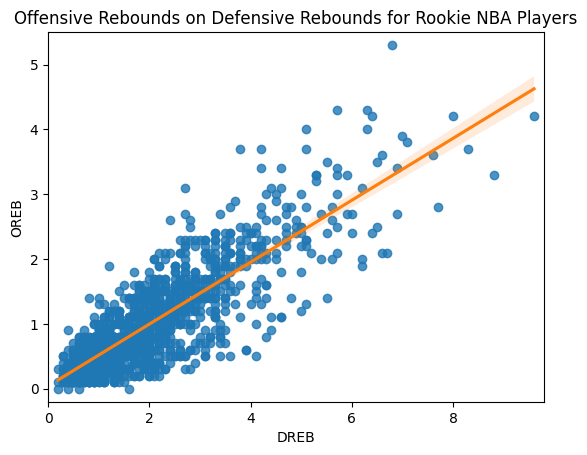

In [16]:
scattreg(df_nba.DREB, df_nba.OREB)
plt.title('Offensive Rebounds on Defensive Rebounds for Rookie NBA Players')

Here, we see perhaps the strongest and most linear scatterplot yet, which makes sense as players who could rebound the ball on one side of the court should theoretically also be able to rebound the ball on the other side of the court. Additionally, larger, taller players are usually the stronger rebounders in general, so naturally they would like have a relatively high number of defensive and offensive rebounds per game.\
\
Now, let's get a little more obscure--let's look at steals and turnovers.

Text(0.5, 1.0, 'Turnovers on Steals for Rookie NBA Players')

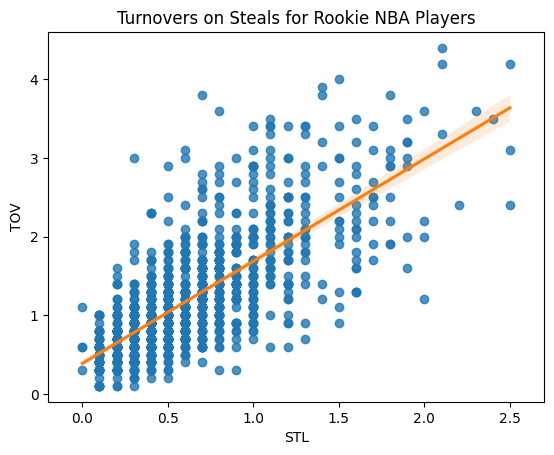

In [17]:
scattreg(df_nba.STL, df_nba.TOV)
plt.title('Turnovers on Steals for Rookie NBA Players')

Here, we see surprisingly linear relationship between the two statistics. However, it could be explained with many different explations. First, steals is a defensive metric and turnovers is on offense, implying that some players who may excel defensively may lack offensive power. Another explanation could be that those with many steals play more minutes per game and/or have more possesions per game than those who don't have as many steals, meaning that they would naturally have more turnovers as a result of handling the ball more often.\
\
Now, let's turn to two statistics which are seemingly unrelated, considering that they may be the most offensive statistic and most defensive statistic--points and blocks.

Text(0.5, 1.0, 'Blocks on Points for Rookie NBA Players')

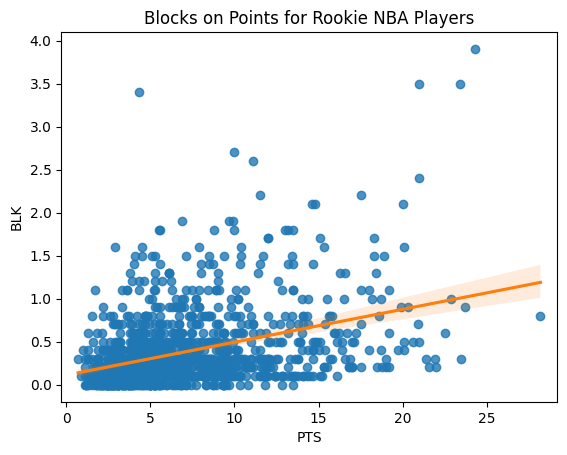

In [18]:
scattreg(df_nba.PTS, df_nba.BLK)
plt.title('Blocks on Points for Rookie NBA Players')

Despite one statistic being mainly offensive and the other being mainly defensive, there is still a slight correlation between the two. My theory as to why this is is because those who block more shots also excel offensively, especially around the rim. We can see this in players like Shaq and David Robinson (who have a high number of blocks and points, but we'll talk about that more in Part 4). However, this idea of strong defense and strong offense is weakened when we look at assists and blocks...

Text(0.5, 1.0, 'Blocks on Assists for Rookie NBA Players')

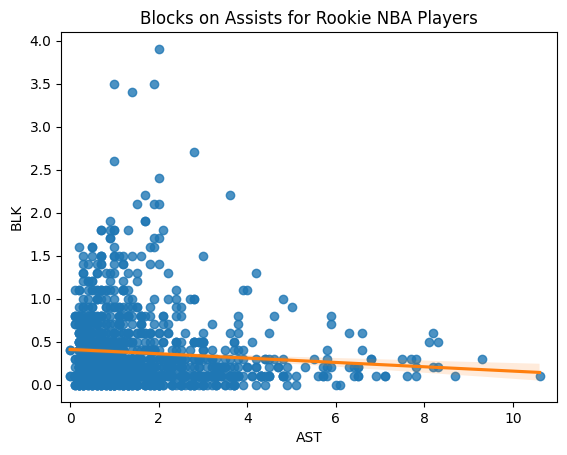

In [19]:
scattreg(df_nba.AST, df_nba.BLK)
plt.xlim(-0.2, 11) # the automated x-limit on this specific graph is weird, so this is to make it less weird
plt.title('Blocks on Assists for Rookie NBA Players')

Here, we actually see a *negative* trend between assists and blocks; those who score multiple blocks and points per game as shown in the previous chart now are on the lower end of assists. However, this makes sense--those having multiple assists per game are likely either shorter players (who mainly play point guard, a pass-heavy position) or players who aren't good shooters or point-makers, and just stick to what they're good at. The reason why those who get many blocks per game don't usually have relatively that many assists to other players, as opposed to points, is because those who block more are again, likely larger and taller players, meaning that they have the ability to dominate other players. Not only when blocking their shots, but also when driving in or posting up in the paint (meaning that either they drive the ball to the hoop, or others pass to them to get a clean bucket).\
\
Finally, to cap this section off, let's look at offensive and defensive rating to see if there truly is a relationship between the two.

Text(0.5, 1.0, 'Defensive Rating on Offensive Rating for Rookie NBA Players')

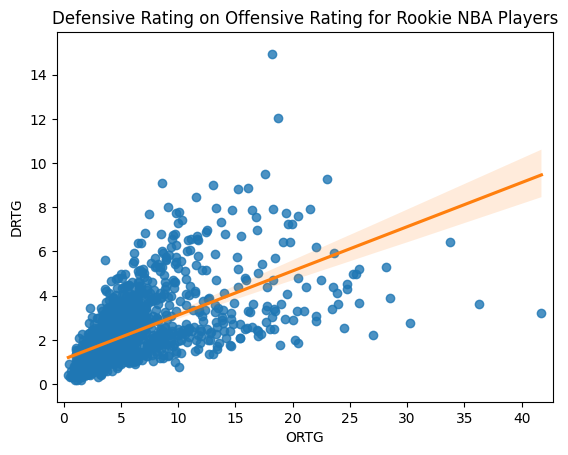

In [20]:
scattreg(df_nba.ORTG, df_nba.DRTG)
plt.title('Defensive Rating on Offensive Rating for Rookie NBA Players')

Here, we see a roughly linear and positive relationship between the variables, which makes sense as great players would likely be good offensively and defensively.

## Part 4: Who's the Best?
The penultimate part of this notebook is to deduce who had the best rookie season (or at least, statistically speaking the best rookie season). First, let's look at the most basic statistic, points, and see who the top 10 leaders in the category are.\
\
**Note: All graphs shown in this part have adjusted y-limits in order to emphasize the differences between the players' stats**

In [21]:
df_pts = df_nba.sort_values(by=['PTS'])
df_pts

,Name,GP,MIN,PTS,FGS,FGA,TPM,TPA,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,ORTG,DRTG
165,Mike Williams,21,4.9,0.7,0.3,0.9,0.0,0.0,0.1,0.3,0.2,0.9,0.1,0.1,0.3,0.1,0.51,0.93
783,Mario West,64,4.2,0.9,0.3,0.8,0.0,0.1,0.3,0.4,0.4,0.3,0.2,0.2,0.1,0.1,0.72,0.32
669,Cole Aldrich,18,7.9,1.0,0.4,0.8,0.0,0.0,0.1,0.2,0.7,1.2,0.2,0.3,0.4,0.4,1.12,1.32
1197,Todd Mundt,33,4.6,1.1,0.5,1.2,0.0,0.0,0.2,0.2,0.3,0.5,0.1,0.1,0.1,0.1,0.81,0.51
164,Eric Johnson,48,5.7,1.1,0.4,1.8,0.0,0.1,0.3,0.4,0.2,0.4,1.3,0.3,0.0,0.5,0.78,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1277,Shaquille O'Neal*,81,37.9,23.4,9.0,16.1,0.0,0.0,5.3,8.9,4.2,9.6,1.9,0.7,3.5,3.8,18.76,12.05
1127,Allen Iverson*,76,40.1,23.5,8.2,19.8,2.0,6.0,5.0,7.2,1.5,2.6,7.5,2.1,0.3,4.4,41.73,3.23
421,Terry Cummings,70,36.2,23.7,9.8,18.7,0.0,0.0,4.2,5.9,4.3,6.3,2.5,1.8,0.9,2.9,21.51,7.92
115,David Robinson*,82,36.6,24.3,8.4,15.9,0.0,0.0,7.5,10.2,3.7,8.3,2.0,1.7,3.9,3.1,18.18,14.93


Text(0.5, 1.0, 'Top 10 NBA Rookies with the Highest Average PPG')

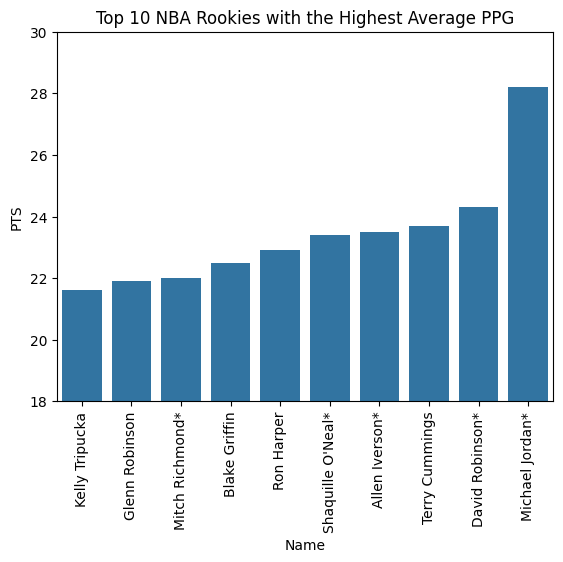

In [22]:
sns.barplot(y=df_pts.tail(10).PTS,x=df_pts.tail(10).Name)
plt.xticks(rotation = 'vertical') # To make the names legible on the graph
plt.ylim(18,30)
plt.title('Top 10 NBA Rookies with the Highest Average PPG')

Here are the top 10 players with the highest average points per game. Here, we see most of the players float between 22-24 points per game, which while still extremely impressive (for any player in the league in fact, especially for a **ROOKIE**), is nothing compared to Michael Jordan, who has an average points per game of **OVER 28**, which is far above everyone else in the league, including those in the top 10, when regarding points per game.\
\
Beyond statstics, let's look at their overall ratings. First up are the top 10 players with the highest offensive ratings.

Text(0.5, 1.0, 'Top 10 NBA Rookies with the Highest Average ORTG')

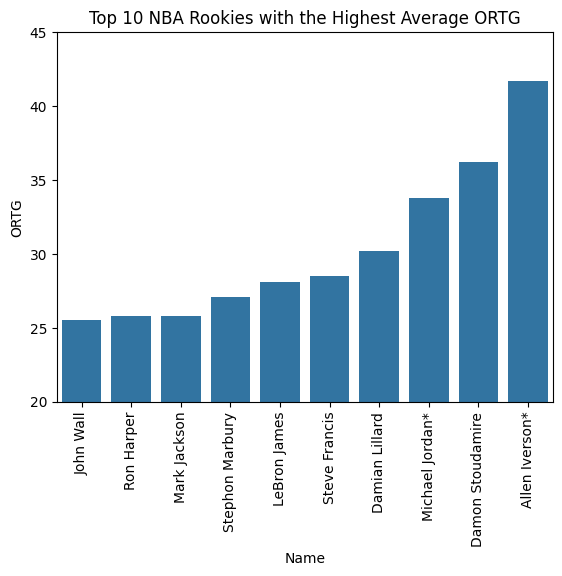

In [23]:
df_ortg = df_nba.sort_values(by=['ORTG'])
sns.barplot(y=df_ortg.tail(10).ORTG,x=df_ortg.tail(10).Name)
plt.xticks(rotation = 'vertical')
plt.ylim(20, 45)
plt.title('Top 10 NBA Rookies with the Highest Average ORTG')

We see something interesting here that makes it different from the PTS graph--the gradual increase in the statistic up until the leader in that statistic. In the PTS graph, places 10-2 are relatively close, while #1 is far and away clearly the better player at getting points. However, in the ORTG graph, places 10-8 are relatively close, 7-4 are slightly further apart, and 3-1 are even further apart from each other.\
\
Now, let's look at the players' defensive ratings.

Text(0.5, 1.0, 'Top 10 NBA Rookies with the Highest Average DRTG')

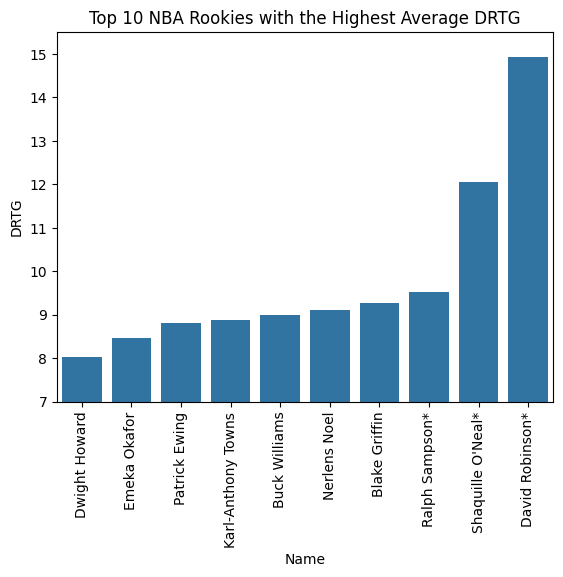

In [24]:
df_drtg = df_nba.sort_values(by=['DRTG'])
sns.barplot(y=df_drtg.tail(10).DRTG,x=df_drtg.tail(10).Name)
plt.xticks(rotation = 'vertical')
plt.ylim(7, 15.5)
plt.title('Top 10 NBA Rookies with the Highest Average DRTG')

Here, in terms of the shape of the distribution, we see kind of a mix between the PTS and the ORTG graph. In the DRTG graph, places 10-8 are slightly spaced apart, places 8-3 are relatively similar to each other, #2 is far above places 3-10, and #1 is far above #2.\
\
Now, let's look at the players' *overall* rating! This was calculated by adding each player's offensive rating and 1.5 times their defensive rating (since in this notebook's calculations of offensive and defensive ratings, the highest offensive ratings are far greater than the highest defensive ratings, so multiplying the defensive ratings by 1.5 makes the two more equal in terms of weight). We have to create the series for this statistic first, and then we can look at the graph.

In [25]:
rtg = round((df_nba.ORTG + df_nba.DRTG * 1.5), 2)
df_nba['OVR'] = pd.Series(rtg)
df_nba

,Name,GP,MIN,PTS,FGS,FGA,TPM,TPA,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,ORTG,DRTG,OVR
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,0.5,2.1,1.6,2.3,0.7,3.4,1.9,0.4,0.4,1.3,5.86,3.56,11.20
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,0.7,2.8,2.6,3.4,0.5,2.0,3.7,1.1,0.5,1.6,7.65,2.55,11.48
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,0.4,1.7,0.9,1.3,0.5,1.7,1.0,0.5,0.3,1.0,3.51,1.85,6.28
3,Malik Sealy,58,11.6,5.7,2.3,5.5,0.1,0.5,0.9,1.3,1.0,0.9,0.8,0.6,0.1,1.0,3.96,0.96,5.40
4,Matt Geiger,48,11.5,4.5,1.6,3.0,0.0,0.1,1.3,1.9,1.0,1.5,0.3,0.3,0.4,0.8,2.77,1.62,5.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303,Chris Smith,80,15.8,4.3,1.6,3.6,0.0,0.2,1.2,1.5,0.4,0.8,2.5,0.6,0.2,0.8,3.34,0.92,4.72
1304,Brent Price,68,12.6,3.9,1.5,4.1,0.1,0.7,0.8,1.0,0.4,1.1,2.3,0.8,0.0,1.3,3.10,1.10,4.75
1305,Marlon Maxey,43,12.1,5.4,2.2,3.9,0.0,0.0,1.0,1.6,1.5,2.3,0.3,0.3,0.4,0.9,3.90,2.42,7.53
1306,Litterial Green,52,12.0,4.5,1.7,3.8,0.0,0.2,1.2,1.8,0.2,0.4,2.2,0.4,0.1,0.8,3.14,0.44,3.80


Text(0.5, 1.0, 'Top 10 Best Rookie Years')

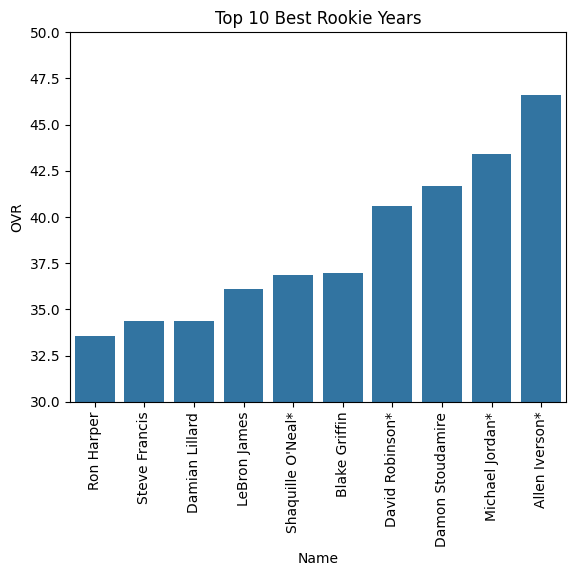

In [26]:
df_ovr = df_nba.sort_values(by=['OVR'])
sns.barplot(y=df_ovr.tail(10).OVR,x=df_ovr.tail(10).Name)
plt.xticks(rotation = 'vertical')
plt.ylim(30, 50)
plt.title('Top 10 Best Rookie Years')

Here is, according to our calculations, the top 10 players with the best overall rookie year. This makes sense, as we see a lot of players who are a part of the "greats," such as Shaq, MJ, Allen Iverson, and LeBron. The greater weighting in defensive rating also helped players like David Robinson and Shaq (although Shaq's offensive rating was high as well) place high in the list. However, players with ridiculously high offensive ratings, such as Stoudamire, Jordan, and Iverson, still triumphed the list, which makes sense as the only people that fans say had a better rookie season than Iverson were players that aren't on the list (too old) such as Wilt Chamberlain, Larry Bird, and Magic Johnson.

## Part 5: Reflection

I have learned a lot from this project. Compared to the rest of the course, we didn't have much time to cover and explore data science and using data science tools in Python, so it was nice to spend many hours discovering and learning more about Pandas and Seaborn. Trying to find out what specific functions to use for what I want for both Pandas and Seaborn was by far the hardest part about the project. There's just so much stuff you could do with each library, so the documentation for each library was my best friend while creating the project.\
\
Overall, this project was a great way for me to become more comfortable with using these libraries and to learn more about how data science actually works. It was also cool to see all of the statistics for all of these players, as well as to compare them to each other, to see trends in data, and to see relationships between these statistics.
#### References/Inspiration
[Here's the original Kaggle notebook](https://www.kaggle.com/code/tombutton/predicting-nba-success/notebook), which contains the data that I used. The way that this notebook and the original notebook differ is that the original notebook's main goal is to try and predict success based on an NBA player's rookie year, while this notebook's main goal is to compare and contrast statistics for many NBA players.\
\
I also used the documentation pages for [Pandas](https://pandas.pydata.org/docs/), [MatPlotLib](https://matplotlib.org/stable/index.html), and [Seaborn](https://seaborn.pydata.org/api.html) in order to find exactly what I am looking to do with each library, as well as to teach me how to use certain functions.